In [ ]:
## Notebook for loading the simulation data from the first update to the 1D model
## Using surface temperatures 180K, 210K, 255K and 285K

In [1]:
## Imports

import iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import iris.plot as iplt
import iris.quickplot as qplt
import iris.analysis.cartography
import iris.analysis
import aeolus
import aeolus.calc
import aeolus.coord
import matplotlib.colors as mcolors
import matplotlib.ticker


import warnings
warnings.filterwarnings("ignore")


In [2]:
## Load the model output for the original Aglyamov et al. (2021) model when ran over the five surface pressures
temp_180 = iris.load('/home/jj22956/exo_lightning_msci_project/src_onebar/data/plume_model_output/plume_model_output_default.nc')
temp_210 = iris.load('/home/jj22956/exo_lightning_msci_project/src_onebar/data/plume_model_output/plume_model_output_run01.nc')
temp_255 = iris.load('/home/jj22956/exo_lightning_msci_project/src_onebar/data/plume_model_output/plume_model_output_run02.nc')
temp_285 = iris.load('/home/jj22956/exo_lightning_msci_project/src_onebar/data/plume_model_output/plume_model_output_run03.nc')


In [ ]:
## Extraction functions for each cube

def plume_velocity(cube):
    return cube.extract_cube('velocity')
    
def plume_temp(cube):
    return cube.extract_cube('plume_temp')

def env_temp(cube):
    return cube.extract_cube('env_temp')

def plume_env_temp(cube):
    return cube.extract_cube('plume_temp') - cube.extract_cube('env_temp')

def plume_radius(cube):
    return cube.extract_cube('plume_radius')

def LFR(cube):
    return cube.extract_cube('flash_rate')


In [ ]:
## In case the sigma pressures ever want to be calulated
one_surfacepressure = 1e5

In [ ]:
## Load the vertical plume velocity cubes

t180_velocity = plume_velocity(temp_180)
t180_pressures = t180_velocity.coord("air_pressure").points * 1e-5
t210_velocity = plume_velocity(temp_210)
t210_pressures = t210_velocity.coord("air_pressure").points * 1e-5
t255_velocity = plume_velocity(temp_255)
t255_pressures = t255_velocity.coord("air_pressure").points * 1e-5
t285_velocity = plume_velocity(temp_285)
t285_pressures = t285_velocity.coord("air_pressure").points * 1e-5



In [ ]:
## Load the plume-environment temperature cubes

t180_plume_env_temp = plume_env_temp(temp_180)
t210_plume_env_temp = plume_env_temp(temp_210)
t255_plume_env_temp = plume_env_temp(temp_255)
t285_plume_env_temp = plume_env_temp(temp_285)

In [ ]:
## Load the radius cubes

t180_radius = plume_radius(temp_180)
t210_radius = plume_radius(temp_210)
t255_radius = plume_radius(temp_255)
t285_radius = plume_radius(temp_285)

In [ ]:
## Load the lightning flash rate (LFR) cubes

t180_LFR = LFR(temp_180)
t180_LFR_pressures = t180_LFR.coord("air_pressure").points * 1e-5

t210_LFR = LFR(temp_210)
t210_LFR_pressures = t210_LFR.coord("air_pressure").points * 1e-5

t255_LFR = LFR(temp_255)
t255_LFR_pressures = t255_LFR.coord("air_pressure").points * 1e-5

t285_LFR = LFR(temp_285)
t285_LFR_pressures = t285_LFR.coord("air_pressure").points * 1e-5

In [ ]:
## Plotting the vertical plume velocities as a function of air pressure

# plt.plot(t180_velocity.data, t180_pressures, label='180 K')
# plt.plot(t210_velocity.data, t210_pressures, label='210 K')
# plt.plot(t255_velocity.data, t255_pressures, label='255 K')
# plt.plot(t285_velocity.data, t285_pressures, label='285 K')

# plt.gca().invert_yaxis()
# plt.grid(color='lightgrey')
# plt.xlabel(r'Vertical Plume Velocity [m s$^{-1}$]')
# plt.ylabel('Pressure [bar]')
# plt.legend()
# plt.savefig('/data/cluster4/jj22956/initial_run_figures/velocity.pdf')
# plt.show()



In [ ]:
## Plotting the plume-environment temperature difference as a function of air pressure


# plt.plot(t180_plume_env_temp.data, t180_pressures, label='180 K')
# plt.plot(t210_plume_env_temp.data, t210_pressures, label='210 K')
# plt.plot(t255_plume_env_temp.data, t255_pressures, label='255 K')
# plt.plot(t285_plume_env_temp.data, t285_pressures, label='285 K')

# plt.gca().invert_yaxis()
# plt.grid(color='lightgrey')
# plt.xlabel('Temperature difference [K]')
# plt.ylabel('Pressure [bar]')
# plt.legend()
# plt.savefig('/data/cluster4/jj22956/initial_run_figures/plume_env_temp.pdf')
# plt.show()



In [ ]:
## Plotting the plume radii as a function of air pressure

# plt.plot(t180_radius.data, t180_pressures, label='180 K')
# plt.plot(t210_radius.data, t210_pressures, label='210 K')
# plt.plot(t255_radius.data, t255_pressures, label='255 K')
# plt.plot(t285_radius.data, t285_pressures, label='285 K')
# plt.gca().invert_yaxis()
# plt.grid(color='lightgrey')
# plt.xlabel('Radius [m]')
# plt.ylabel('Pressure [bar]')
# plt.legend()
# plt.savefig('/data/cluster4/jj22956/initial_run_figures/radius.pdf')
# plt.show()



In [ ]:
## Plotting the LFR throughout the plume as a function of air pressure

# plt.plot(t180_LFR.data, t180_LFR_pressures, label='180 K')
# plt.plot(t210_LFR.data, t210_LFR_pressures, label='210 K')
# plt.plot(t255_LFR.data, t255_LFR_pressures, label='255 K')
# plt.plot(t285_LFR.data, t285_LFR_pressures, label='285 K')
# plt.gca().invert_yaxis()
# plt.grid(color='lightgrey')
# plt.xlabel(r'LFR [flashes s$^{-1}$ km$^{2}$]')
# plt.ylabel('Pressure [bar]')
# plt.legend()
# plt.savefig('/data/cluster4/jj22956/initial_run_figures/LFR.pdf')
# plt.show()



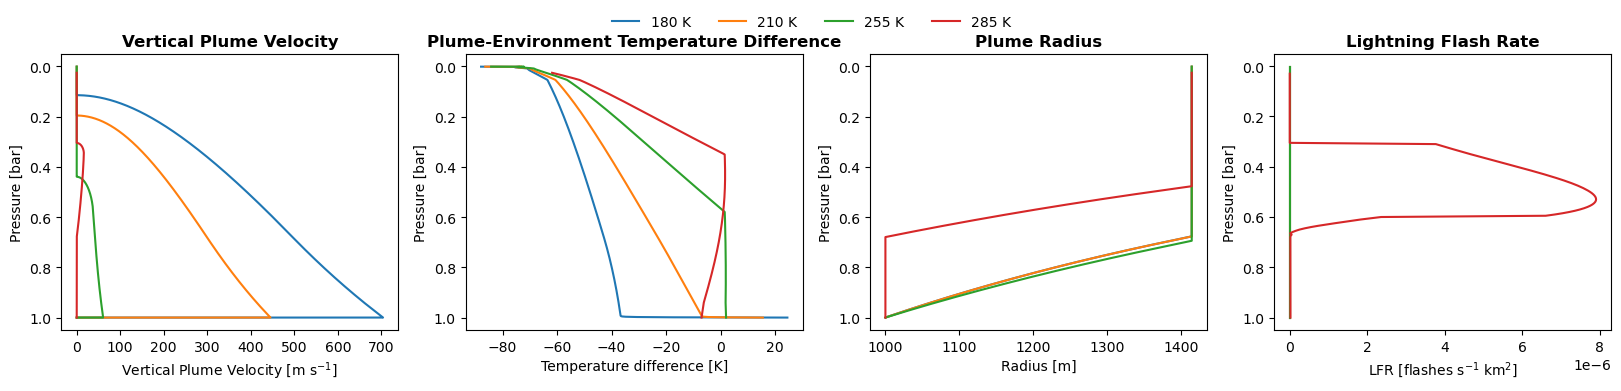

In [ ]:
## Subplotting the four plume characteristics above for each surface temperature case

initial_fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 4))
initial_fig.suptitle('', fontsize='x-large', weight='bold')

ax1.plot(t180_velocity.data, t180_pressures, label='180 K')
ax1.plot(t210_velocity.data, t210_pressures, label='210 K')
ax1.plot(t255_velocity.data, t255_pressures, label='255 K')
ax1.plot(t285_velocity.data, t285_pressures, label='285 K')
ax1.invert_yaxis()
ax1.set_xlabel(r'Vertical Plume Velocity [m s$^{-1}$]')
ax1.set_ylabel('Pressure [bar]')
ax1.set_title('Vertical Plume Velocity', weight='bold')



ax2.plot(t180_plume_env_temp.data, t180_pressures)
ax2.plot(t210_plume_env_temp.data, t210_pressures)
ax2.plot(t255_plume_env_temp.data, t255_pressures)
ax2.plot(t285_plume_env_temp.data, t285_pressures)
ax2.invert_yaxis()
ax2.set_xlabel('Temperature difference [K]')
ax2.set_ylabel('Pressure [bar]')
ax2.set_title('Plume-Environment Temperature Difference', weight='bold')

ax3.plot(t180_radius.data, t180_pressures)
ax3.plot(t210_radius.data, t210_pressures)
ax3.plot(t255_radius.data, t255_pressures)
ax3.plot(t285_radius.data, t285_pressures)
ax3.invert_yaxis()
ax3.set_xlabel('Radius [m]')
ax3.set_ylabel('Pressure [bar]')
ax3.set_title('Plume Radius', weight='bold')

ax4.plot(t180_LFR.data, t180_LFR_pressures)
ax4.plot(t210_LFR.data, t210_LFR_pressures)
ax4.plot(t255_LFR.data, t255_LFR_pressures)
ax4.plot(t285_LFR.data, t285_LFR_pressures)
ax4.invert_yaxis()
ax4.set_xlabel(r'LFR [flashes s$^{-1}$ km$^{2}$]')
ax4.set_ylabel('Pressure [bar]')
ax4.set_title('Lightning Flash Rate', weight='bold')



initial_fig.legend(
    ncols=5,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.93),
    frameon=False
)

initial_fig.subplots_adjust(top=0.8)


initial_fig.savefig(
    '/data/cluster4/jj22956/initial_run_figures/initial_plots_full.pdf',
    bbox_inches="tight",
    pad_inches=0
)


initial_fig.savefig(
    '/data/cluster4/jj22956/initial_run_figures/initial_plots_full.pdf',
    bbox_inches="tight",
    pad_inches=0
)
